In [ ]:
!pip install opencv-python-headless scikit-image matplotlib numpy -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
MASTER_IMAGE_PATH = '/content/drive/MyDrive/datalength/ok/train/imag1 (202).jpeg'   # your master image path

TEST_IMAGES_FOLDER = '/content/drive/MyDrive/datalength/ok/test_images/'  # your test images folder

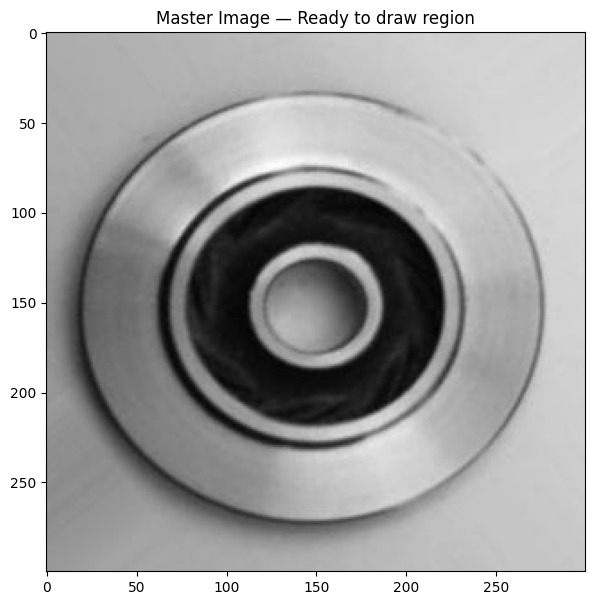

Image size: (300, 300, 3)


In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

master_img = cv2.imread(MASTER_IMAGE_PATH)
master_img_rgb = cv2.cvtColor(master_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(master_img_rgb)
plt.title('Master Image — Ready to draw region')
plt.axis('on')
plt.show()

print('Image size:', master_img_rgb.shape)


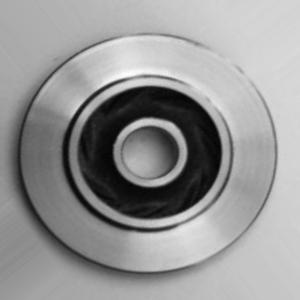

In [ ]:
import base64
import cv2
from IPython.display import display, HTML

# Convert master image to base64 for HTML
_, buffer = cv2.imencode('.jpg', cv2.cvtColor(master_img_rgb, cv2.COLOR_RGB2BGR))
img_base64 = base64.b64encode(buffer).decode('utf-8')

html_code = f"""
<h3>🖱️ Click TOP-LEFT then BOTTOM-RIGHT of your region</h3>
<p id="status">Clicks: 0/2</p>
<p id="coords" style="font-size:18px; color:green; font-weight:bold;"></p>

<div style="position:relative; display:inline-block;">
  <img id="img" src="data:image/jpeg;base64,{img_base64}"
       style="max-width:900px; cursor:crosshair;"
       onclick="getClick(event)"/>
  <canvas id="overlay" style="position:absolute; top:0; left:0; pointer-events:none;"></canvas>
</div>

<script>
var clicks = [];
var img = document.getElementById('img');
var canvas = document.getElementById('overlay');
var ctx = canvas.getContext('2d');

img.onload = function() {{
  canvas.width = img.width;
  canvas.height = img.height;
}};

function getClick(e) {{
  var rect = img.getBoundingClientRect();
  var scaleX = img.naturalWidth / img.width;
  var scaleY = img.naturalHeight / img.height;
  var x = Math.round((e.clientX - rect.left) * scaleX);
  var y = Math.round((e.clientY - rect.top) * scaleY);

  clicks.push({{x, y}});

  // Draw dot
  ctx.fillStyle = clicks.length === 1 ? 'lime' : 'red';
  ctx.beginPath();
  ctx.arc((e.clientX - rect.left), (e.clientY - rect.top), 6, 0, 2*Math.PI);
  ctx.fill();

  document.getElementById('status').innerText = 'Clicks: ' + clicks.length + '/2';

  if (clicks.length === 2) {{
    var x1 = Math.min(clicks[0].x, clicks[1].x);
    var y1 = Math.min(clicks[0].y, clicks[1].y);
    var x2 = Math.max(clicks[0].x, clicks[1].x);
    var y2 = Math.max(clicks[0].y, clicks[1].y);

    // Draw rectangle
    ctx.strokeStyle = 'lime';
    ctx.lineWidth = 3;
    ctx.strokeRect(
      Math.min(clicks[0].x/scaleX, clicks[1].x/scaleX),
      Math.min(clicks[0].y/scaleY, clicks[1].y/scaleY),
      Math.abs(clicks[1].x/scaleX - clicks[0].x/scaleX),
      Math.abs(clicks[1].y/scaleY - clicks[0].y/scaleY)
    );

    document.getElementById('coords').innerHTML =
      '✅ x1=' + x1 + ' y1=' + y1 + ' x2=' + x2 + ' y2=' + y2 +
      '<br>📋 Copy these into next cell!';

    clicks = []; // reset for new selection
  }}
}}
</script>
"""

display(HTML(html_code))

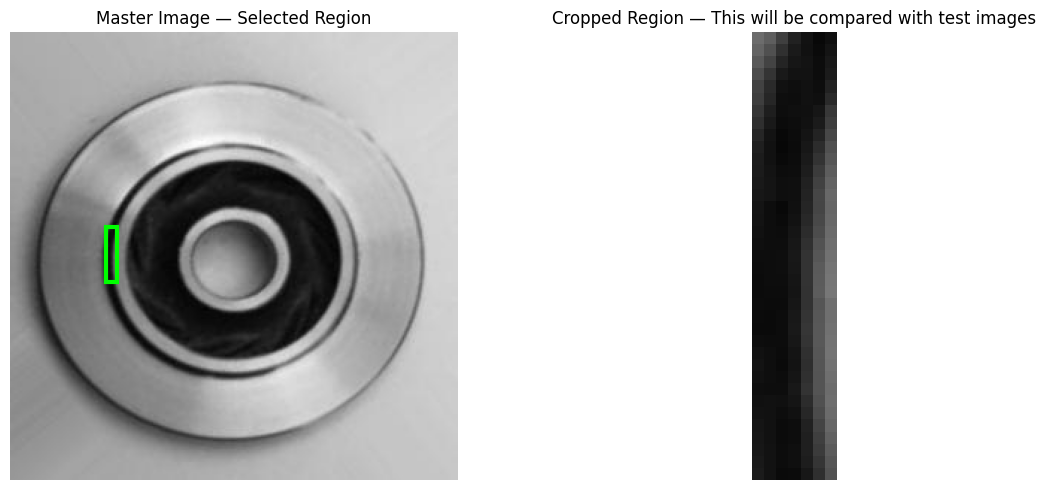

✅ Region confirmed! Size: 7 x 37 pixels


In [ ]:
import matplotlib.patches as patches

x1, y1, x2, y2 = 64,130,71,167
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full master with green box
axes[0].imshow(master_img_rgb)
rect = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                          linewidth=3, edgecolor='lime', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('Master Image — Selected Region')
axes[0].axis('off')

# Cropped region
master_region = master_img_rgb[y1:y2, x1:x2]
axes[1].imshow(master_region)
axes[1].set_title('Cropped Region — This will be compared with test images')
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f'✅ Region confirmed! Size: {x2-x1} x {y2-y1} pixels')

In [ ]:
from skimage.metrics import structural_similarity as ssim
from pathlib import Path
import cv2
import numpy as np

# ── THRESHOLD SETTINGS ──────────────────
SSIM_THRESHOLD  = 0.85   # structural similarity
MSE_THRESHOLD   = 500    # pixel error (lower = stricter)
HIST_THRESHOLD  = 0.95   # histogram match
# ────────────────────────────────────────

def preprocess(img):
    """Normalize brightness and contrast so lighting doesn't affect result"""
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    normalized = cv2.equalizeHist(gray)
    return normalized

def calc_mse(img1, img2):
    """Mean Squared Error — sensitive to even tiny pixel changes"""
    return float(np.mean((img1.astype(float) - img2.astype(float)) ** 2))

def calc_hist(img1, img2):
    """Histogram comparison — catches brightness/color shifts"""
    h1 = cv2.calcHist([img1], [0], None, [256], [0,256])
    h2 = cv2.calcHist([img2], [0], None, [256], [0,256])
    return cv2.compareHist(h1, h2, cv2.HISTCMP_CORREL)

def get_confidence(ssim_score, mse_score, hist_score):
    """Return confidence level based on all 3 scores"""
    passed = 0
    if ssim_score >= SSIM_THRESHOLD:  passed += 1
    if mse_score  <= MSE_THRESHOLD:   passed += 1
    if hist_score >= HIST_THRESHOLD:  passed += 1

    if passed == 3:   return 'PASS', 'HIGH'
    elif passed == 0: return 'FAIL', 'HIGH'
    elif passed >= 2: return 'PASS', 'MEDIUM'
    else:             return 'FAIL', 'MEDIUM'

# ── LOAD TEST IMAGES ─────────────────────
supported_exts = {'.jpg', '.jpeg', '.png', '.bmp'}
test_images = sorted([
    f for f in Path(TEST_IMAGES_FOLDER).iterdir()
    if f.suffix.lower() in supported_exts
])

print(f'📦 Found {len(test_images)} test images\n')
print('=' * 70)

# Preprocess master region once
master_pre = preprocess(master_region)

results = []

for i, img_path in enumerate(test_images, 1):
    try:
        test_img     = cv2.imread(str(img_path))
        test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
        test_region  = test_img_rgb[y1:y2, x1:x2]
        test_resized = cv2.resize(test_region,
                                  (master_region.shape[1], master_region.shape[0]))

        # Preprocess test region
        test_pre = preprocess(test_resized)

        # Calculate all 3 scores
        ssim_score = ssim(master_pre, test_pre)
        mse_score  = calc_mse(master_pre, test_pre)
        hist_score = calc_hist(master_pre, test_pre)

        similarity = round(ssim_score * 100, 4)
        difference = round((1 - ssim_score) * 100, 4)

        result, confidence = get_confidence(ssim_score, mse_score, hist_score)
        icon = '✅' if result == 'PASS' else '❌'

        print(f'[{i}] {img_path.name}')
        print(f'     SSIM  : {round(ssim_score,4)}  MSE: {round(mse_score,2)}  HIST: {round(hist_score,4)}')
        print(f'     Result: {icon} {result}  |  Confidence: {confidence}')
        print('-' * 70)

        results.append({
            'file'      : img_path.name,
            'ssim'      : round(ssim_score, 4),
            'mse'       : round(mse_score, 2),
            'hist'      : round(hist_score, 4),
            'similarity': similarity,
            'difference': difference,
            'result'    : result,
            'confidence': confidence,
            'region'    : test_resized
        })

    except Exception as e:
        print(f'[{i}] {img_path.name} → ⚠️ ERROR: {e}')

passed = sum(1 for r in results if r['result'] == 'PASS')
failed = sum(1 for r in results if r['result'] == 'FAIL')
print(f'\n📊 DONE!  ✅ PASS: {passed}  |  ❌ FAIL: {failed}  |  Total: {len(results)}')

📦 Found 203 test images

[1] Copy of imag1 (201).jpeg
     SSIM  : 0.3193  MSE: 7909.21  HIST: -0.0277
     Result: ❌ FAIL  |  Confidence: HIGH
----------------------------------------------------------------------
[2] Copy of imag1 (202) (1).jpeg
     SSIM  : 1.0  MSE: 0.0  HIST: 1.0
     Result: ✅ PASS  |  Confidence: HIGH
----------------------------------------------------------------------
[3] Copy of imag1 (202).jpeg
     SSIM  : 1.0  MSE: 0.0  HIST: 1.0
     Result: ✅ PASS  |  Confidence: HIGH
----------------------------------------------------------------------
[4] imag1 (1).jpeg
     SSIM  : 0.635  MSE: 4396.7  HIST: 0.0394
     Result: ❌ FAIL  |  Confidence: HIGH
----------------------------------------------------------------------
[5] imag1 (10).jpeg
     SSIM  : 0.8803  MSE: 1453.4  HIST: -0.0574
     Result: ❌ FAIL  |  Confidence: MEDIUM
----------------------------------------------------------------------
[6] imag1 (100).jpeg
     SSIM  : -0.0539  MSE: 10982.05  HIST: 

In [ ]:
from IPython.display import display, HTML

passed = sum(1 for r in results if r['result'] == 'PASS')
failed = sum(1 for r in results if r['result'] == 'FAIL')
total  = len(results)
p_pct  = round(passed/total*100) if total else 0
f_pct  = round(failed/total*100) if total else 0

rows_html = ''
for i, r in enumerate(results, 1):
    color = '#00c853' if r['result'] == 'PASS' else '#d50000'
    bg    = '#f1fff6' if r['result'] == 'PASS' else '#fff1f1'
    icon  = '✅ PASS' if r['result'] == 'PASS' else '❌ FAIL'
    conf_color = '#1565c0' if r['confidence'] == 'HIGH' else '#f57c00'

    rows_html += f"""
    <tr style="background:{bg};">
        <td style="padding:10px; text-align:center; font-weight:bold;">{i}</td>
        <td style="padding:10px;">{r['file']}</td>
        <td style="padding:10px; text-align:center;">{r['ssim']}</td>
        <td style="padding:10px; text-align:center;">{r['mse']}</td>
        <td style="padding:10px; text-align:center;">{r['hist']}</td>
        <td style="padding:10px; text-align:center;">{r['similarity']}%</td>
        <td style="padding:10px; text-align:center; color:{color};
                   font-weight:bold;">{r['difference']}%</td>
        <td style="padding:10px; text-align:center; font-weight:bold;
                   color:{conf_color};">{r['confidence']}</td>
        <td style="padding:10px; text-align:center; font-size:15px;
                   font-weight:bold; color:{color};">{icon}</td>
    </tr>
    """

alert_bar = ''
if failed > 0:
    alert_bar = f"""
    <style>@keyframes blink {{ 50% {{ opacity:0; }} }}</style>
    <div style="background:#d50000; color:white; padding:14px;
                border-radius:10px; font-size:20px; font-weight:bold;
                text-align:center; margin-bottom:20px;
                animation:blink 1s step-start infinite;">
        🚨 ALERT! {failed} part(s) FAILED — Immediate check required!
    </div>
    """

dashboard = f"""
<div style="font-family:Arial,sans-serif; padding:20px;
            background:#f5f5f5; border-radius:16px;">

    <h2 style="text-align:center; color:#333;">
        🏭 Production Line — AI Inspection Dashboard
    </h2>

    {alert_bar}

    <div style="display:flex; gap:16px; margin-bottom:24px; justify-content:center;">
        <div style="background:#00c853; color:white; padding:16px 32px;
                    border-radius:10px; font-size:20px; font-weight:bold; text-align:center;">
            ✅ PASS<br>{passed} ({p_pct}%)
        </div>
        <div style="background:#d50000; color:white; padding:16px 32px;
                    border-radius:10px; font-size:20px; font-weight:bold; text-align:center;">
            ❌ FAIL<br>{failed} ({f_pct}%)
        </div>
        <div style="background:#1565c0; color:white; padding:16px 32px;
                    border-radius:10px; font-size:20px; font-weight:bold; text-align:center;">
            📦 TOTAL<br>{total}
        </div>
    </div>

    <table style="width:100%; border-collapse:collapse; background:white;
                  border-radius:10px; overflow:hidden;
                  box-shadow:2px 2px 8px rgba(0,0,0,0.1);">
        <thead>
            <tr style="background:#1565c0; color:white; font-size:13px;">
                <th style="padding:10px;">#</th>
                <th style="padding:10px; text-align:left;">Image</th>
                <th style="padding:10px;">SSIM</th>
                <th style="padding:10px;">MSE</th>
                <th style="padding:10px;">HIST</th>
                <th style="padding:10px;">Similarity</th>
                <th style="padding:10px;">Difference</th>
                <th style="padding:10px;">Confidence</th>
                <th style="padding:10px;">Result</th>
            </tr>
        </thead>
        <tbody>
            {rows_html}
        </tbody>
    </table>
</div>
"""

display(HTML(dashboard))

#,Image,SSIM,MSE,HIST,Similarity,Difference,Confidence,Result
1,Copy of imag1 (201).jpeg,0.3193,7909.21,-0.0277,31.9298%,68.0702%,HIGH,❌ FAIL
2,Copy of imag1 (202) (1).jpeg,1.0,0.0,1.0,100.0%,0.0%,HIGH,✅ PASS
3,Copy of imag1 (202).jpeg,1.0,0.0,1.0,100.0%,0.0%,HIGH,✅ PASS
4,imag1 (1).jpeg,0.635,4396.7,0.0394,63.5009%,36.4991%,HIGH,❌ FAIL
5,imag1 (10).jpeg,0.8803,1453.4,-0.0574,88.0316%,11.9684%,MEDIUM,❌ FAIL
6,imag1 (100).jpeg,-0.0539,10982.05,-0.0694,-5.3895%,105.3895%,HIGH,❌ FAIL
7,imag1 (101).jpeg,0.1909,9213.92,-0.0587,19.0946%,80.9054%,HIGH,❌ FAIL
8,imag1 (102).jpeg,0.6993,3963.59,0.0934,69.9323%,30.0677%,HIGH,❌ FAIL
9,imag1 (103).jpeg,0.6148,4998.48,-0.0067,61.4766%,38.5234%,HIGH,❌ FAIL
10,imag1 (104).jpeg,-0.2612,14082.37,0.0232,-26.1248%,126.1248%,HIGH,❌ FAIL


In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Reload master image
master_img     = cv2.imread(MASTER_IMAGE_PATH)
master_img_rgb = cv2.cvtColor(master_img, cv2.COLOR_BGR2RGB)

print(f'Image size → Height:{master_img_rgb.shape[0]} Width:{master_img_rgb.shape[1]}')
print(f'Your region → x1:{x1} y1:{y1} x2:{x2} y2:{y2}')

# Check if coordinates are within image
if x2 > master_img_rgb.shape[1] or y2 > master_img_rgb.shape[0]:
    print('❌ Coordinates are OUTSIDE image! Need to reselect region!')
else:
    print('✅ Coordinates are valid!')
    master_region = master_img_rgb[y1:y2, x1:x2]
    print(f'Region size → {master_region.shape}')

Image size → Height:300 Width:300
Your region → x1:64 y1:130 x2:71 y2:167
✅ Coordinates are valid!
Region size → (37, 7, 3)
